## Welcome to Week 4, Day 4

This is the start of an AWESOME project! Really simple and very effective.

In [1]:
import pkg_resources

for pkg in ["langchain", "langchain_core", "langchain_openai"]:
    try:
        version = pkg_resources.get_distribution(pkg).version
    except pkg_resources.DistributionNotFound:
        version = None
    print(f"{pkg}: {version}")

# Try importing a helper to check for API changes
try:
    from langchain_core.messages.base import _extract_reasoning_from_additional_kwargs
    print("Import of _extract_reasoning_from_additional_kwargs succeeded")
except Exception as e:
    print(f"Import failed: {e!r}")

/tmp/ipykernel_27284/1707264749.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


langchain: 0.3.27
langchain_core: 1.2.17
langchain_openai: 0.3.35
Import of _extract_reasoning_from_additional_kwargs succeeded


In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_core.tools import Tool

from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver

# langchain_google_genai often lags behind langchain_core; import safely
try:
    from langchain_google_genai import ChatGoogleGenerativeAI
except ImportError as e:
    print("warning: unable to import langchain_google_genai:", e)
    ChatGoogleGenerativeAI = None

In [3]:
load_dotenv(override=True)

True

### Asynchronous LangGraph

To run a tool:  
Sync: `tool.run(inputs)`  
Async: `await tool.arun(inputs)`

To invoke the graph:  
Sync: `graph.invoke(state)`  
Async: `await graph.ainvoke(state)`

In [4]:
class State(TypedDict):
    
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [5]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send a push notification to the user"""
    requests.post(pushover_url, data = {"token": pushover_token, "user": pushover_user, "message": text})

tool_push = Tool(
        name="send_push_notification",
        func=push,
        description="useful for when you want to send a push notification"
    )

## Extra installation step - if you don't have Node and Playwright on your computer

Next, you need to install NodeJS and Playwright on your computer if you don't already have them. Please see instructions here:

[Node and Playwright setup](../setup/SETUP-node.md)

## And now - after Installing Playwright, a heads up for Windows PC Users:

While executing the next few cells, you might hit a problem with the Playwright browser raising a NotImplementedError.

This should work when we move to python modules, but it can cause problems in Windows in a notebook.

If you it this error and would like to run the notebook, you need to make a small change which seems quite hacky! You need to do this AFTER installing Playwright (prior cells)

1. Right click in `.venv` in the File Explorer on the left and select "Find in folder"
2. Search for `asyncio.set_event_loop_policy(WindowsSelectorEventLoopPolicy())`  
3. That code should be found in a line of code in a file called `kernelapp.py`
4. Comment out the entire else clause that this line is a part of - see the fragment below. Be sure to have the "pass" statement after the ImportError line.
5. Restart the kernel by pressing the "Restart" button above

```python
        if sys.platform.startswith("win") and sys.version_info >= (3, 8):
            import asyncio
 
            try:
                from asyncio import WindowsProactorEventLoopPolicy, WindowsSelectorEventLoopPolicy
            except ImportError:
                pass
                # not affected
           # else:
            #    if type(asyncio.get_event_loop_policy()) is WindowsProactorEventLoopPolicy:
                    # WindowsProactorEventLoopPolicy is not compatible with tornado 6
                    # fallback to the pre-3.8 default of Selector
                    # asyncio.set_event_loop_policy(WindowsSelectorEventLoopPolicy())
```

Thank you to student Nicolas for finding this, and to Kalyan, Yaki, Zibin and Bhaskar for confirming that this worked for them! And to Vladislav for the extra pointers.

As an alternative, you can just move to a Python module (which we do anyway in Day 5)

In [6]:
# Introducing nest_asyncio
# Python async code only allows for one "event loop" processing aynchronous events.
# The `nest_asyncio` library patches this, and is used for special situations, if you need to run a nested event loop.

import nest_asyncio
nest_asyncio.apply()

### The LangChain community

One of the remarkable things about LangChain is the rich community around it.

Check this out:


In [14]:
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser

# If you get a NotImplementedError here or later, see the Heads Up at the top of the notebook

async_browser =  create_async_playwright_browser(headless=True)  # Changed to headless=True (headful mode not available in headless environment)
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()

In [8]:
import subprocess
subprocess.run(["playwright", "install"], check=True)

|                                                                                |   0% of 173.7 MiB
|■■■■■■■■                                                                        |  10% of 173.7 MiB
|■■■■■■■■■■■■■■■■                                                                |  20% of 173.7 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■                                                        |  30% of 173.7 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                                                |  40% of 173.7 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                                        |  50% of 173.7 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                                |  60% of 173.7 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                        |  70% of 173.7 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                |  80% of 173.7 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■        |  90% of 

Playwright Host validation warning: 
╔══════════════════════════════════════════════════════╗
║ Host system is missing dependencies to run browsers. ║
║ Please install them with the following command:      ║
║                                                      ║
║     sudo playwright install-deps                     ║
║                                                      ║
║ Alternatively, use apt:                              ║
║     sudo apt-get install libatk1.0-0t64\             ║
║         libatk-bridge2.0-0t64\                       ║
║         libcups2t64\                                 ║
║         libxkbcommon0\                               ║
║         libatspi2.0-0t64\                            ║
║         libxcomposite1\                              ║
║         libxdamage1\                                 ║
���         libxfixes3\                                  ║
║         libxrandr2\                                  ║
║         libgbm1\                               

CompletedProcess(args=['playwright', 'install'], returncode=0)

In [15]:
import subprocess
import os

# Install system dependencies for Playwright directly
deps = [
    "libatk1.0-0t64",
    "libatk-bridge2.0-0t64",
    "libcups2t64",
    "libxkbcommon0",
    "libatspi2.0-0t64",
    "libxcomposite1",
    "libxdamage1",
    "libxfixes3",
    "libxrandr2",
    "libgbm1",
    "libasound2t64"
]

cmd = ["sudo", "apt-get", "update"]
subprocess.run(cmd, check=False)

cmd = ["sudo", "apt-get", "install", "-y"] + deps
result = subprocess.run(cmd, check=False)
print(f"Installation completed with return code: {result.returncode}")

Hit:1 https://packages.microsoft.com/repos/microsoft-ubuntu-noble-prod noble InRelease
Get:2 https://dl.yarnpkg.com/debian stable InRelease
Hit:3 https://repo.anaconda.com/pkgs/misc/debrepo/conda stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble InRelease
Err:2 https://dl.yarnpkg.com/debian stable InRelease
  The following signatures couldn't be verified because the public key is not available: NO_PUBKEY 62D54FD4003F6525
Hit:5 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists...
Reading package lists...

W: GPG error: https://dl.yarnpkg.com/debian stable InRelease: The following signatures couldn't be verified because the public key is not available: NO_PUBKEY 62D54FD4003F6525
E: The repository 'https://dl.yarnpkg.com/debian stable InRelease' is not signed.



Building dependency tree...
Reading state information...
libatk1.0-0t64 is already the newest version (2.52.0-1build1).
libatk-bridge2.0-0t64 is already the newest version (2.52.0-1build1).
libcups2t64 is already the newest version (2.4.7-1.2ubuntu7.9).
libxkbcommon0 is already the newest version (1.6.0-1build1).
libatspi2.0-0t64 is already the newest version (2.52.0-1build1).
libxcomposite1 is already the newest version (1:0.4.5-1build3).
libxdamage1 is already the newest version (1:1.1.6-1build1).
libxfixes3 is already the newest version (1:6.0.0-2build1).
libxrandr2 is already the newest version (2:1.5.2-2build1).
libgbm1 is already the newest version (25.2.8-0ubuntu0.24.04.1).
libasound2t64 is already the newest version (1.2.11-1ubuntu0.2).
0 upgraded, 0 newly installed, 0 to remove and 131 not upgraded.
Installation completed with return code: 0


In [16]:
for tool in tools:
    print(f"{tool.name}={tool}")

click_element=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/codespace/.cache/ms-playwright/chromium-1187/chrome-linux/chrome> version=140.0.7339.16>
navigate_browser=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/codespace/.cache/ms-playwright/chromium-1187/chrome-linux/chrome> version=140.0.7339.16>
previous_webpage=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/codespace/.cache/ms-playwright/chromium-1187/chrome-linux/chrome> version=140.0.7339.16>
extract_text=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/codespace/.cache/ms-playwright/chromium-1187/chrome-linux/chrome> version=140.0.7339.16>
extract_hyperlinks=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/codespace/.cache/ms-playwright/chromium-1187/chrome-linux/chrome> version=140.0.7339.16>
get_elements=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/

In [27]:
tool_dict = {tool.name:tool for tool in tools}

navigate_tool = tool_dict.get("navigate_browser")
extract_text_tool = tool_dict.get("extract_text")

    
await navigate_tool.arun({"url": "https://g1.globo.com/"})
text = await extract_text_tool.arun({})

In [28]:
import textwrap
print(textwrap.fill(text))

g1 - O portal de notícias da Globo MENU buscar Entrar com Conta Globo
Uma só conta para todos os produtos Globo. É grátis! Utilize o mesmo
login para todos os produtos Globo e receba recomendações e ofertas
exclusivas para você. Entrar Criar uma conta MENU Entrar com Conta
Globo Uma só conta para todos os produtos Globo. É grátis! Utilize o
mesmo login para todos os produtos Globo e receba recomendações e
ofertas exclusivas para você. Entrar Criar uma conta Dono do Banco
Master Daniel Vorcaro chega a prisão no interior de SP e ficará 10
dias isolado em cela Local é conhecido como o novo 'presídio dos
famosos'; veja quem está lá Guerra no Oriente Médio EUA postam vídeo
de ataques no Irã com pontuações por mortes; VÍDEO Número de mortos na
guerra passa de 1.200 Israel mostra vídeo de jato F-35 abatendo caça
do Irã 2 anos desaparecida Laudo aponta que corpo encontrado em
floresta do Canadá é de brasileira Previsão do Tempo São Paulo
Probabilidade de chuva: 38% 5mm manhã tarde noite 29º ma

In [29]:
all_tools = tools + [tool_push]

In [33]:
for tool in tools:
    print(f"{tool.name}={tool}")

click_element=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/codespace/.cache/ms-playwright/chromium-1187/chrome-linux/chrome> version=140.0.7339.16>
navigate_browser=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/codespace/.cache/ms-playwright/chromium-1187/chrome-linux/chrome> version=140.0.7339.16>
previous_webpage=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/codespace/.cache/ms-playwright/chromium-1187/chrome-linux/chrome> version=140.0.7339.16>
extract_text=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/codespace/.cache/ms-playwright/chromium-1187/chrome-linux/chrome> version=140.0.7339.16>
extract_hyperlinks=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/codespace/.cache/ms-playwright/chromium-1187/chrome-linux/chrome> version=140.0.7339.16>
get_elements=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/

In [39]:

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.9)
#llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(all_tools)


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


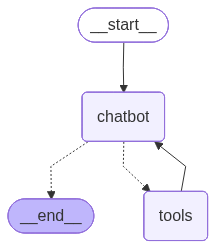

In [40]:

graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=all_tools))
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
config = {"configurable": {"thread_id": "10"}}

async def chat(user_input: str, history):
    result = await graph.ainvoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
